In [5]:
# files to include
report_files = [
    "nbody_acpp_RTX2080TI_report.json",
    "nbody_acpp_RTX3080_report.json",
    "nbody_acpp_RX6600XT_report.json"
]

In [6]:
# fetch the data
import os
import json
import pandas
import re

data = []
for file in os.listdir("../results"):
    is_report_file = False
    for possible_report_file in report_files:
        if file.endswith(possible_report_file):
            is_report_file = True
    if not is_report_file:
        continue
    with open(os.path.join("../results", file), "r") as file:
        json_data = json.load(file)
        local_df = pandas.DataFrame(json_data["benchmarks"])
        local_df = local_df.dropna(subset=["iterations"])
        local_df = local_df[["name", "real_time", "cpu_time", "time_unit", "force_update", "position_update_reset", "velocity_update"]]
        name_size_split = local_df["name"].str.split("/", expand=True)
        details_split = name_size_split[0].str.split("-", expand=True)
        local_df["Precision"] = details_split[1].astype(str)
        local_df["Algorithm"] = details_split[3].astype(str)
        local_df["Sorted"] = details_split[4].astype(str)
        local_df["Problem Size"] = name_size_split[1].astype(int)
        local_df.rename(columns={
            "real_time": "Wall Time",
            "cpu_time": "CPU Time",
            "time_unit": "Time Unit",
            "force_update": "Force Time",
            "position_update_reset": "Position Update",
            "velocity_update": "Velocity Update",
        }, inplace=True)
        local_df["Architecture"] = re.search(r'nbody_acpp_(.*?)_report', str(file)).group(1)
        data.append(local_df)
df = pandas.concat([data[0], data[1], data[2]], ignore_index=True)
df

,name,Wall Time,CPU Time,Time Unit,Force Time,Position Update,Velocity Update,Precision,Algorithm,Sorted,Problem Size,Architecture
0,NBody-Float-AdaptiveCpp-Naive-Sorted/10,1.066792e+08,1.063620e+08,ns,3.190545e+07,3.086826e+07,3.078846e+07,Float,Naive,Sorted,10,RX6600XT
1,NBody-Float-AdaptiveCpp-Naive-Sorted/100,1.089056e+08,1.085640e+08,ns,3.509736e+07,3.107633e+07,3.095063e+07,Float,Naive,Sorted,100,RX6600XT
2,NBody-Float-AdaptiveCpp-Naive-Sorted/1000,1.156196e+08,1.152524e+08,ns,5.078897e+07,3.239231e+07,3.127572e+07,Float,Naive,Sorted,1000,RX6600XT
3,NBody-Float-AdaptiveCpp-Naive-Sorted/10000,1.642233e+08,1.637494e+08,ns,1.404985e+08,2.952831e+07,2.682455e+07,Float,Naive,Sorted,10000,RX6600XT
4,NBody-Float-AdaptiveCpp-Naive-Sorted/100000,1.646517e+09,1.640911e+09,ns,1.484340e+09,2.859973e+07,2.198236e+07,Float,Naive,Sorted,100000,RX6600XT
...,...,...,...,...,...,...,...,...,...,...,...,...
127,NBody-Double-AdaptiveCpp-CellList-Unsorted/100,8.079569e+07,6.180882e+07,ns,2.131047e+08,1.995900e+07,2.008774e+07,Double,CellList,Unsorted,100,RTX2080TI
128,NBody-Double-AdaptiveCpp-CellList-Unsorted/1000,4.286614e+08,4.070710e+08,ns,5.496167e+08,6.449408e+06,5.827568e+06,Double,CellList,Unsorted,1000,RTX2080TI
129,NBody-Double-AdaptiveCpp-CellList-Unsorted/10000,7.009143e+08,6.736149e+08,ns,6.051238e+08,5.008192e+06,4.992736e+06,Double,CellList,Unsorted,10000,RTX2080TI
130,NBody-Double-AdaptiveCpp-CellList-Unsorted/100000,4.313383e+09,4.275870e+09,ns,4.113708e+09,2.594234e+07,2.583581e+07,Double,CellList,Unsorted,100000,RTX2080TI


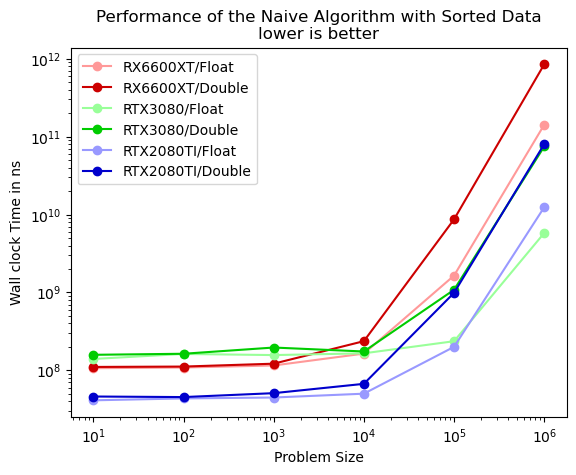

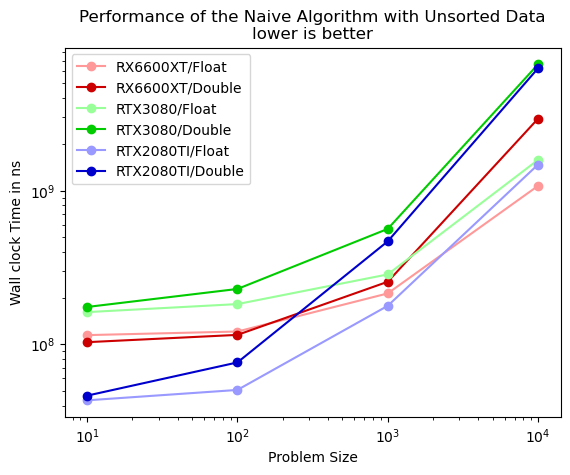

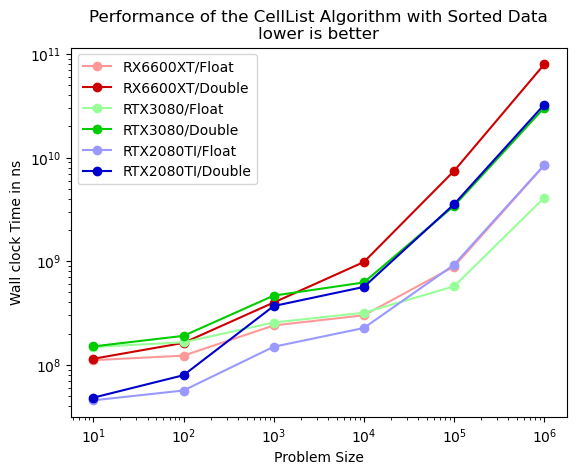

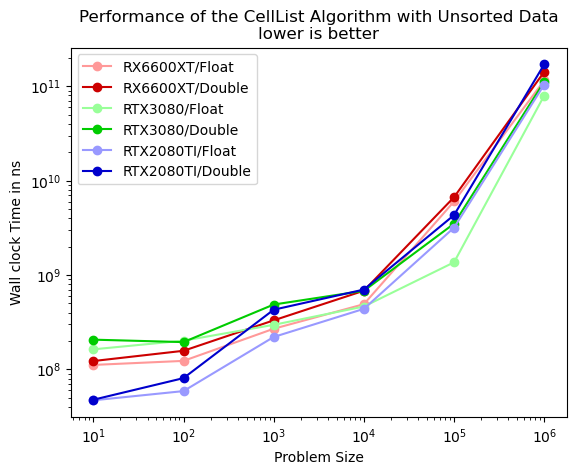

In [25]:
# display the performance of the Algorithm+Sorted
import matplotlib.pyplot as plt

red = ['#FF9999', '#FF6666', '#FF3333', '#CC0000']
green = ['#99FF99', '#66FF66', '#33FF33', '#00CC00'] 
blue = ['#9999FF', '#6666FF', '#3333FF', '#0000CC']

color_map = {"RX6600XT": red, "RTX3080": green, "RTX2080TI": blue}

color_cycler = 0

for algorithm_unique in df["Algorithm"].unique():
    for sorted_unique in df["Sorted"].unique():
        for architecture_unique in df["Architecture"].unique():
            color_cycler = 0
            for precision_unique in df["Precision"].unique():
                subset = df
                subset = subset[subset["Architecture"] == architecture_unique]
                subset = subset[subset["Algorithm"] == algorithm_unique]
                subset = subset[subset["Precision"] == precision_unique]
                subset = subset[subset["Sorted"] == sorted_unique]
                label = str(architecture_unique) + "/" + str(precision_unique)
                plt.plot(subset["Problem Size"], subset["Wall Time"], marker='o', label=label, color=color_map[architecture_unique][color_cycler])
                color_cycler = color_cycler + 3
        plt.yscale("log")
        plt.xscale("log")
        plt.xlabel("Problem Size")
        plt.ylabel("Wall clock Time in "+df["Time Unit"][0])
        plt.title("Performance of the " + algorithm_unique + " Algorithm with " + sorted_unique + " Data\nlower is better")
        plt.legend()
        plt.show()

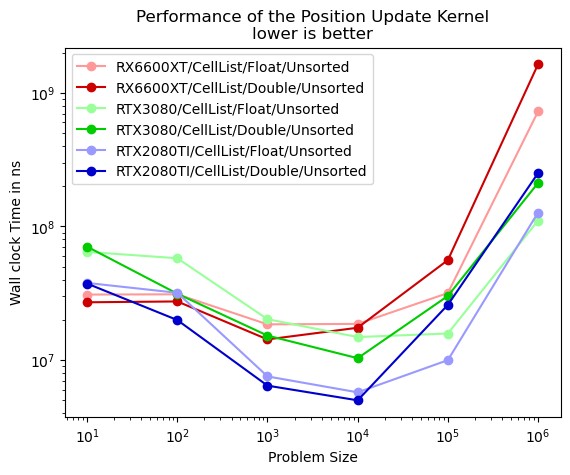

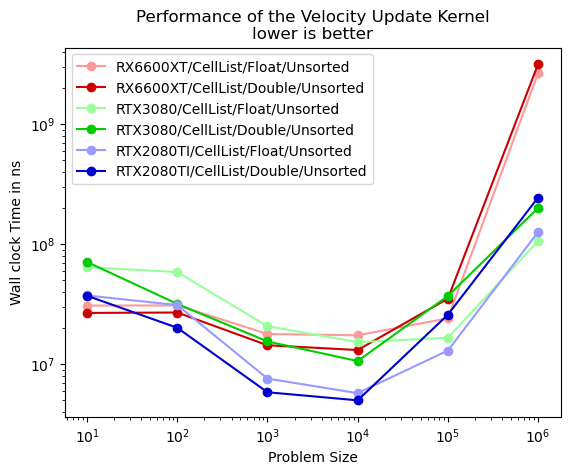

In [27]:
for architecture_unique in df["Architecture"].unique():
    color_cycler = 0
    for precision_unique in df["Precision"].unique():
        subset = df
        subset = subset[subset["Architecture"] == architecture_unique]
        subset = subset[subset["Algorithm"] == "CellList"]
        subset = subset[subset["Precision"] == precision_unique]
        subset = subset[subset["Sorted"] == "Unsorted"]
        label = str(architecture_unique) + "/" + str(algorithm_unique) + "/" + str(precision_unique) + "/" + str(sorted_unique)
        plt.plot(subset["Problem Size"], subset["Position Update"], marker='o', label=label, color=color_map[architecture_unique][color_cycler])
        color_cycler = color_cycler + 3
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Problem Size")
plt.ylabel("Wall clock Time in "+df["Time Unit"][0])
plt.title("Performance of the Position Update Kernel\nlower is better")
plt.legend()
plt.show()
for architecture_unique in df["Architecture"].unique():
    color_cycler = 0
    for precision_unique in df["Precision"].unique():
        subset = df
        subset = subset[subset["Architecture"] == architecture_unique]
        subset = subset[subset["Algorithm"] == "CellList"]
        subset = subset[subset["Precision"] == precision_unique]
        subset = subset[subset["Sorted"] == "Unsorted"]
        label = str(architecture_unique) + "/" + str(algorithm_unique) + "/" + str(precision_unique) + "/" + str(sorted_unique)
        plt.plot(subset["Problem Size"], subset["Velocity Update"], marker='o', label=label, color=color_map[architecture_unique][color_cycler])
        color_cycler = color_cycler + 3
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Problem Size")
plt.ylabel("Wall clock Time in "+df["Time Unit"][0])
plt.title("Performance of the Velocity Update Kernel\nlower is better")
plt.legend()
plt.show()

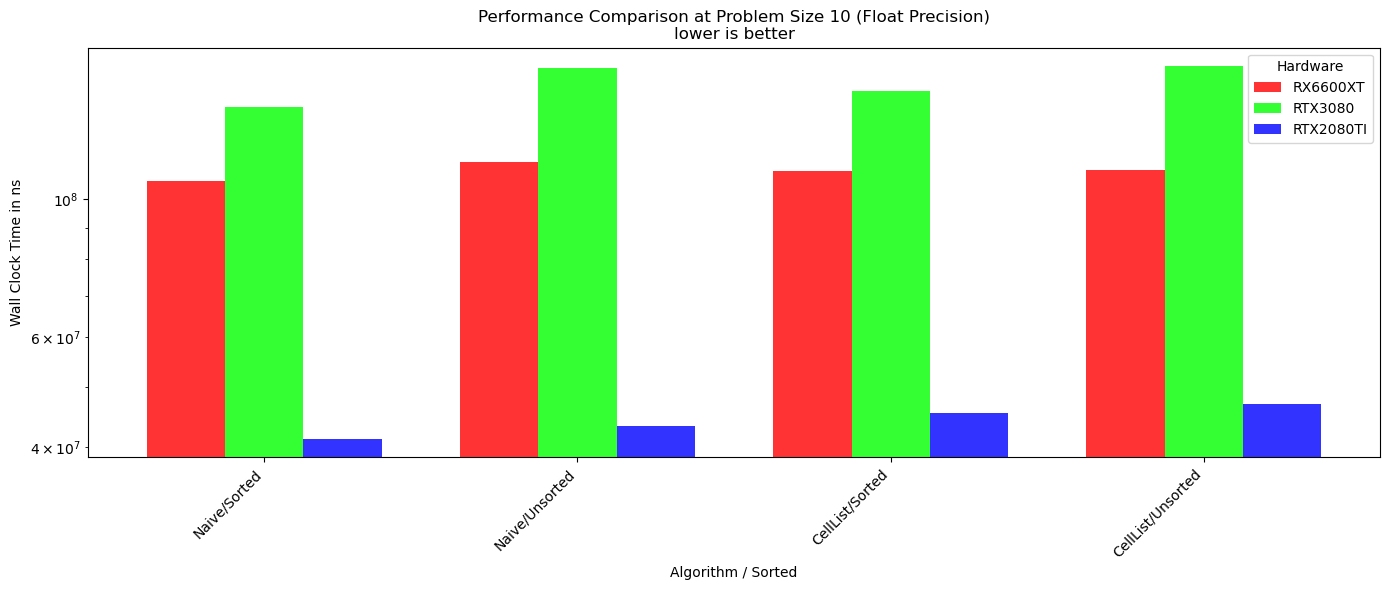

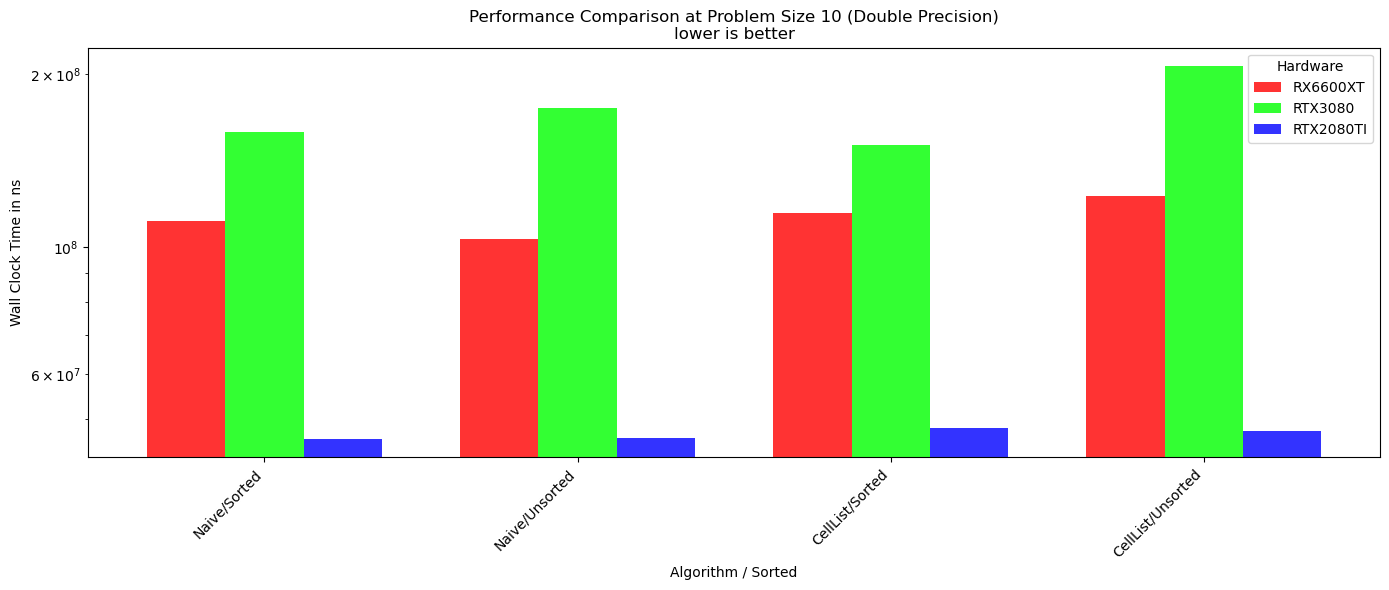

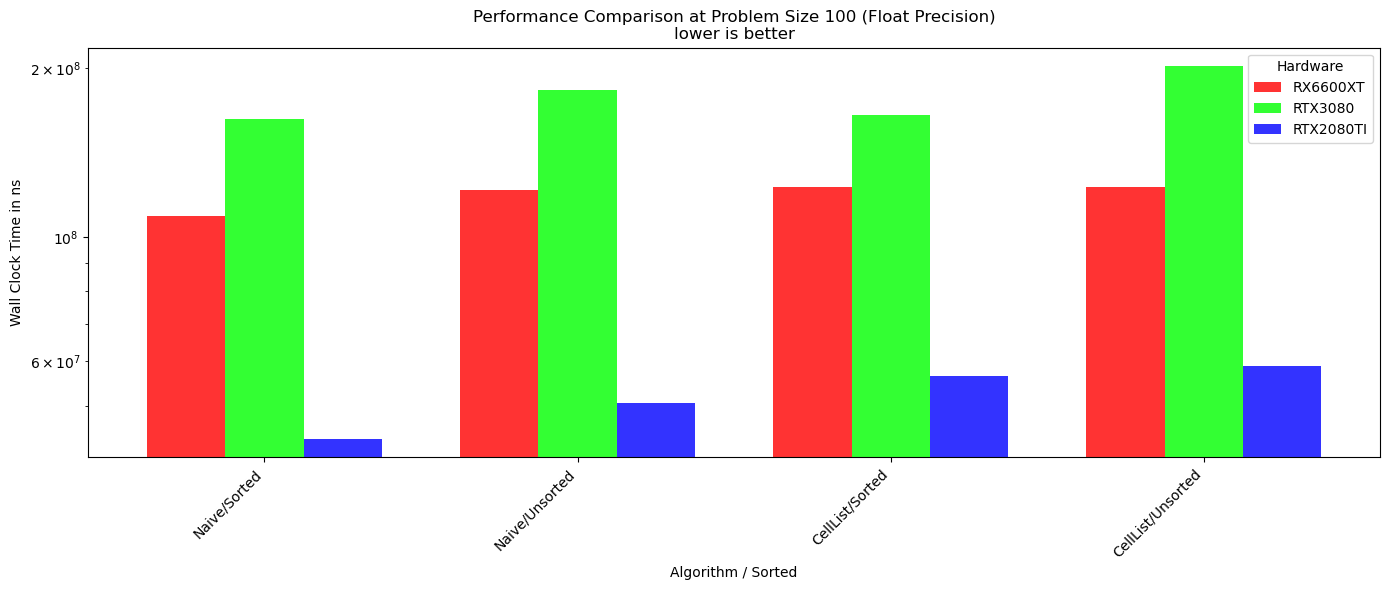

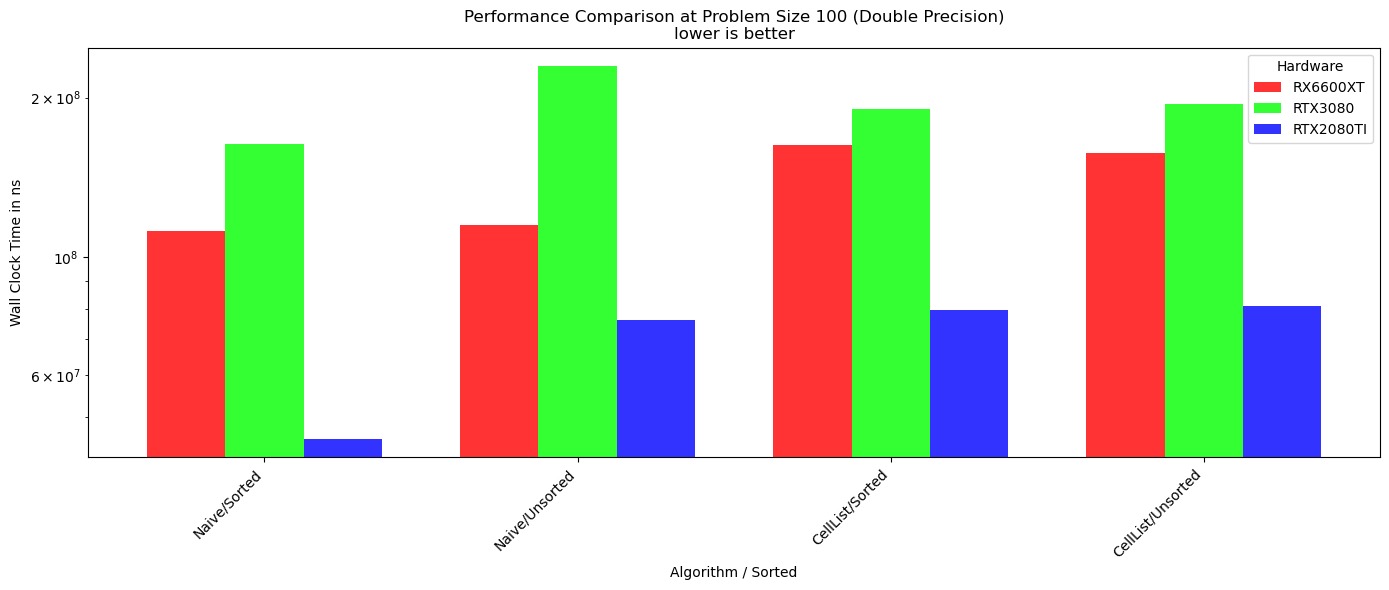

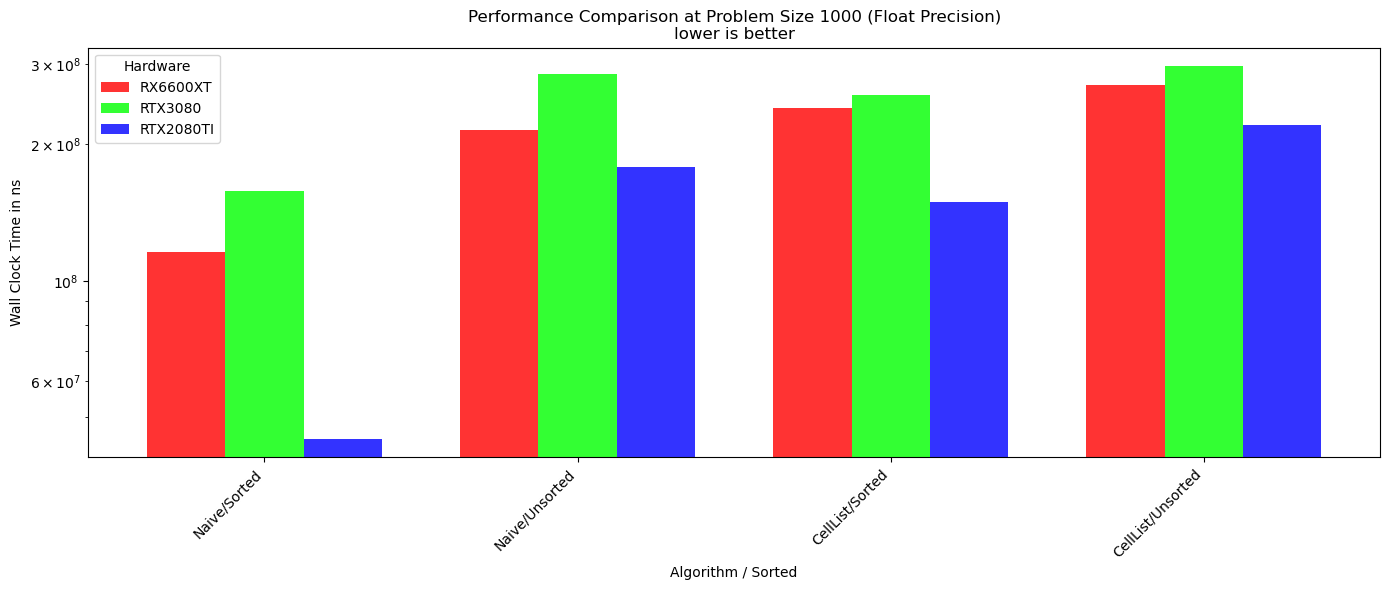

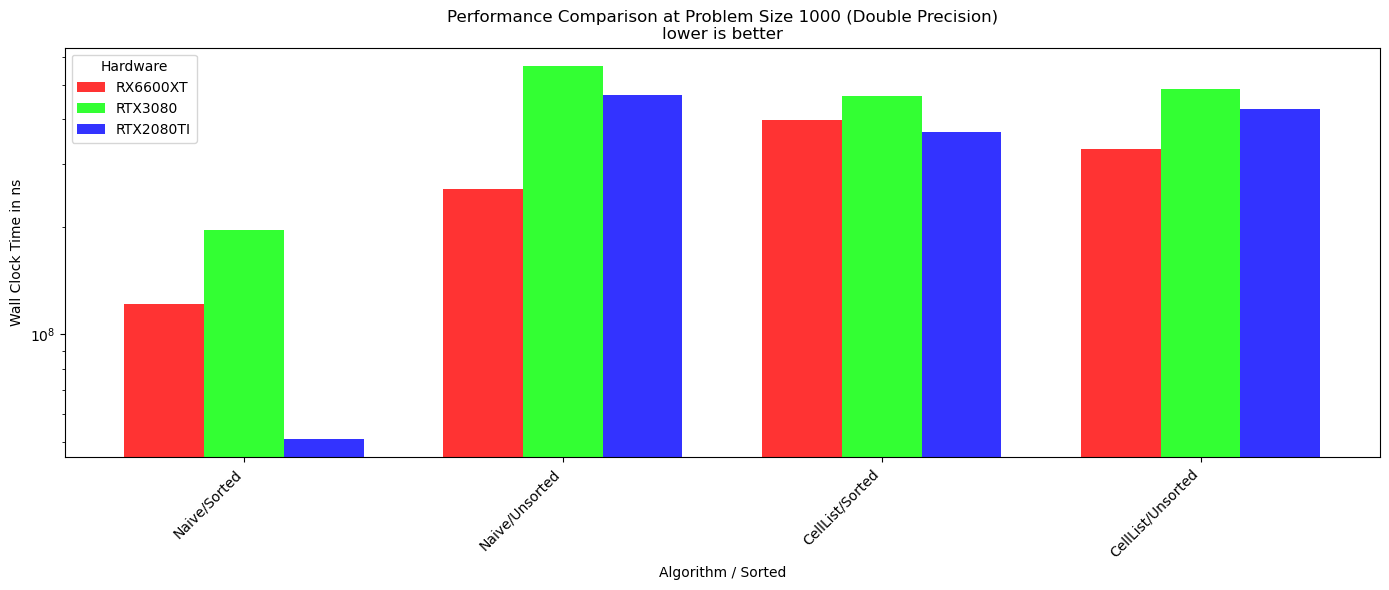

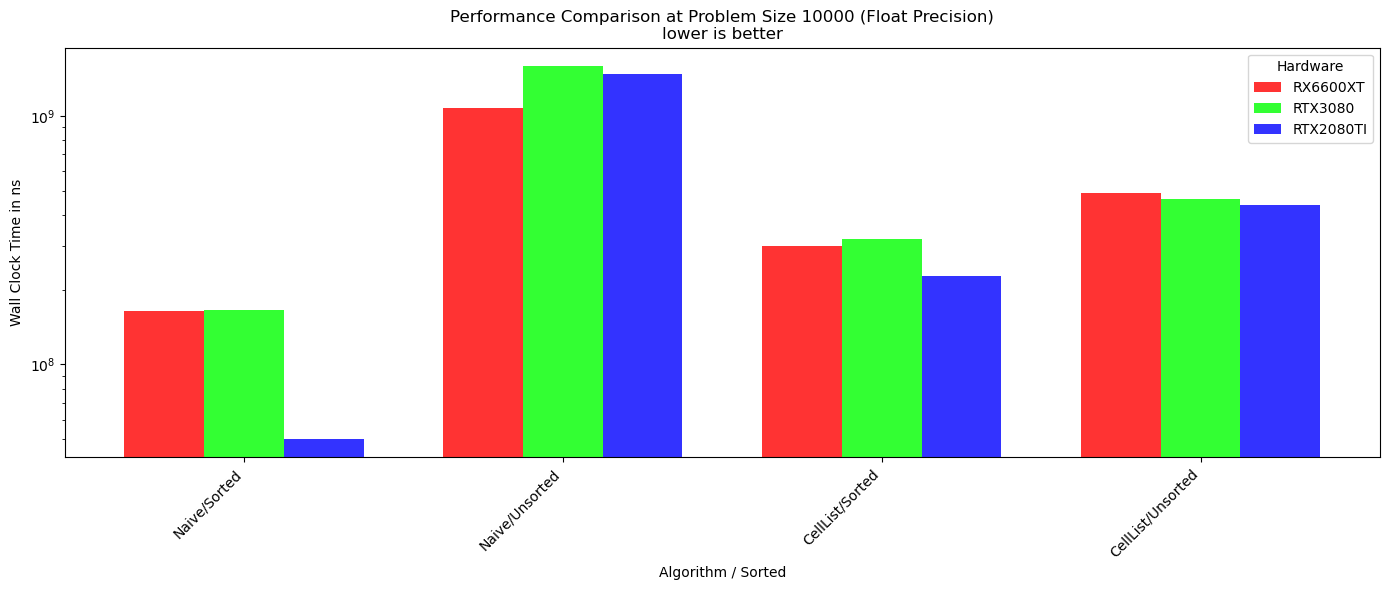

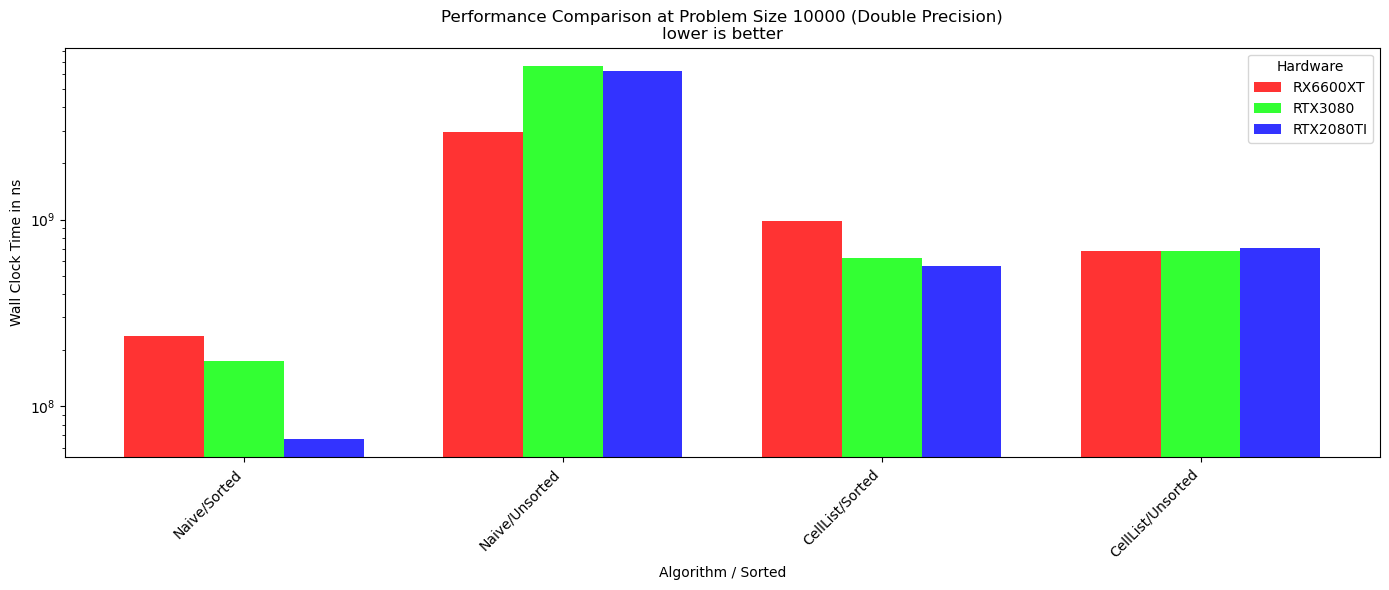

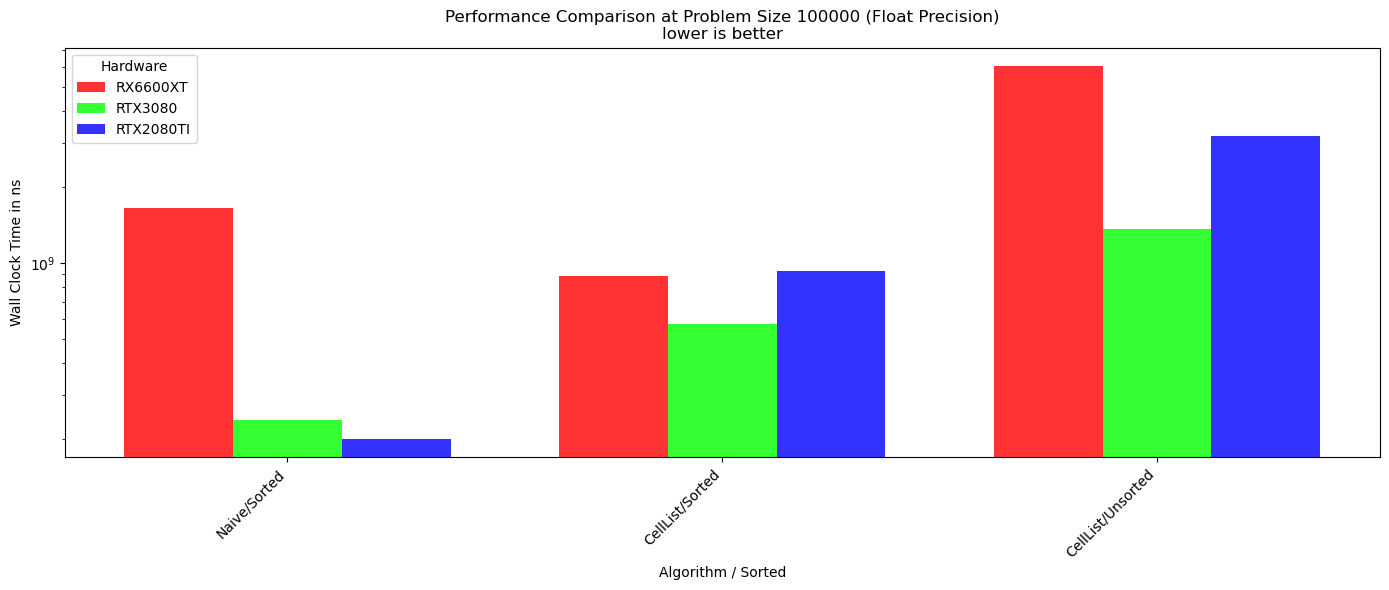

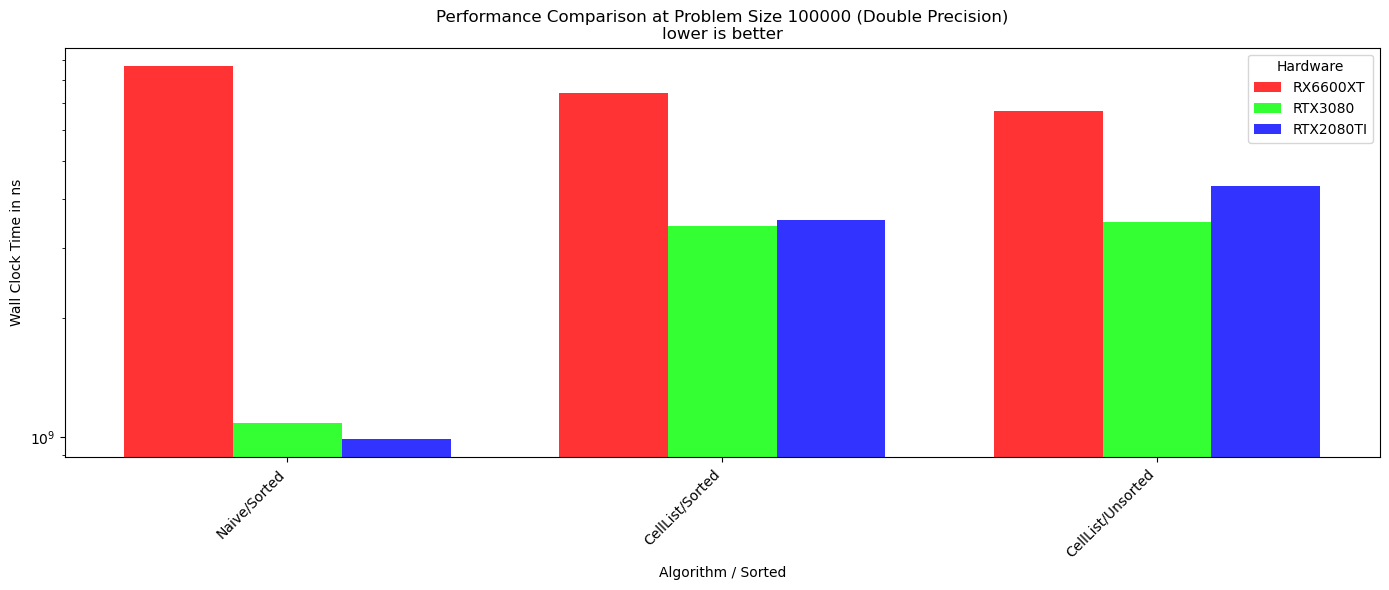

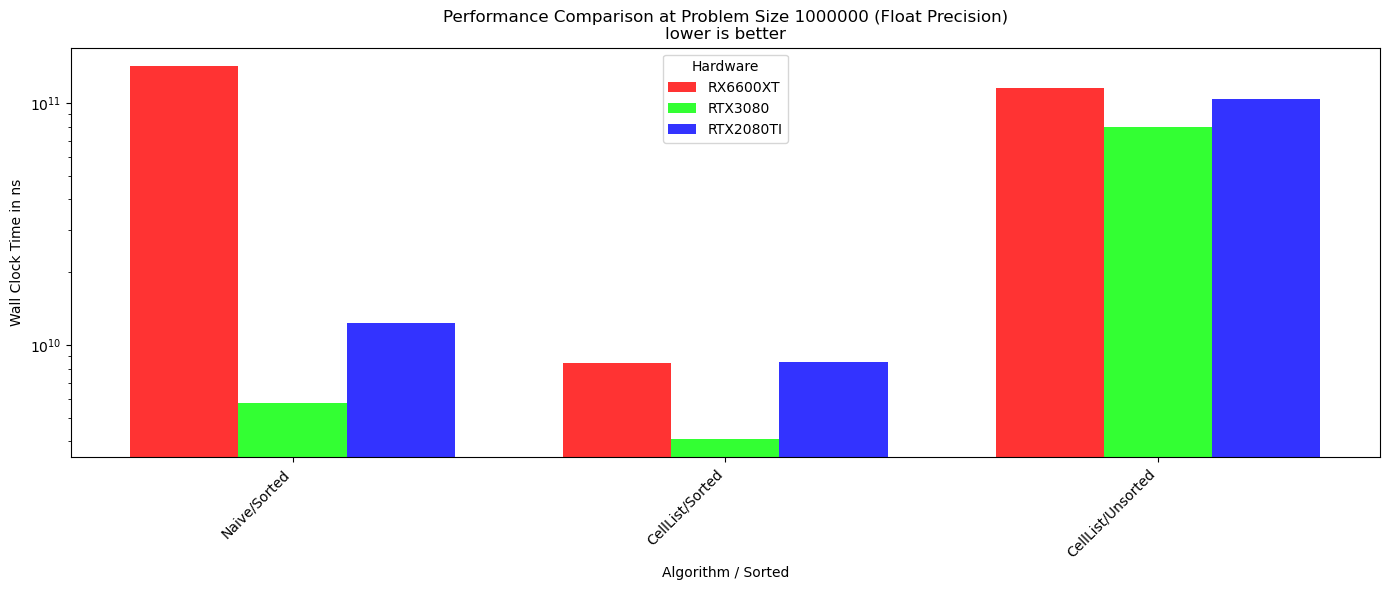

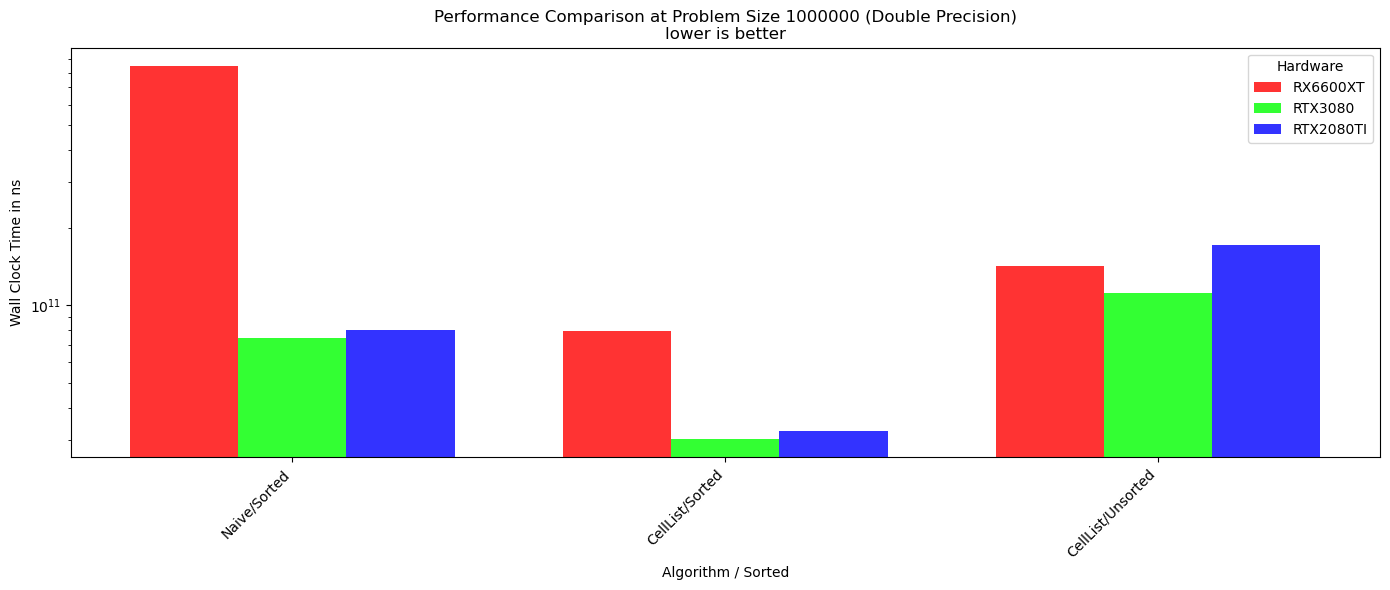

In [39]:
import matplotlib.pyplot as plt
import numpy as np

for problem_size_unique in df["Problem Size"].unique():
    for precision_unique in df["Precision"].unique():
        # Filter the data
        subset = df[df["Problem Size"] == problem_size_unique]
        subset = subset[subset["Precision"] == precision_unique]

        # Get unique values for grouping
        algorithms = subset["Algorithm"].unique()
        sorted_values = subset["Sorted"].unique()
        hardware = subset["Architecture"].unique()

        # Create combinations of Algorithm and Sorted
        combinations = []
        for alg in algorithms:
            for sort in sorted_values:
                if problem_size_unique > 10000 and alg == "Naive" and sort == "Unsorted":
                    continue
                combinations.append(f"{alg}/{sort}")

        # Set up the bar chart
        x = np.arange(len(combinations))
        width = 0.25  # Width of each bar

        fig, ax = plt.subplots(figsize=(14, 6))

        # Color map for hardware
        color_map = {"RX6600XT": '#FF3333', "RTX3080": '#33FF33', "RTX2080TI": '#3333FF'}

        # Plot bars for each hardware type
        for i, hw in enumerate(hardware):
            hw_data = subset[subset["Architecture"] == hw]
            wall_times = []
            for alg in algorithms:
                for sort in sorted_values:
                    if problem_size_unique > 10000 and alg == "Naive" and sort == "Unsorted":
                        continue
                    data = hw_data[(hw_data["Algorithm"] == alg) & (hw_data["Sorted"] == sort)]
                    if len(data) > 0:
                        wall_times.append(data["Wall Time"].values[0])
                    else:
                        wall_times.append(0)
            ax.bar(x + i * width, wall_times, width, label=hw, color=color_map[hw])

        # Customize the chart
        ax.set_xlabel('Algorithm / Sorted')
        ax.set_ylabel('Wall Clock Time in ' + df["Time Unit"].iloc[0])
        ax.set_title('Performance Comparison at Problem Size ' + str(problem_size_unique) + ' (' + str(precision_unique) + ' Precision)\nlower is better')
        ax.set_xticks(x + width)
        ax.set_xticklabels(combinations, rotation=45, ha='right')
        ax.legend(title='Hardware')
        ax.set_yscale('log')

        plt.tight_layout()
        plt.show()

In [49]:
data = [
    # RTX2080TI - Average Occupancy
    ["RTX2080TI", "Average Occupancy", "Naive", "Sorted", "Float", 83.76],
    ["RTX2080TI", "Average Occupancy", "Naive", "Sorted", "Double", 85.50],
    ["RTX2080TI", "Average Occupancy", "Naive", "Unsorted", "Float", 77.30],
    ["RTX2080TI", "Average Occupancy", "Naive", "Unsorted", "Double", 80.79],
    ["RTX2080TI", "Average Occupancy", "CellList", "Sorted", "Float", 78.33],
    ["RTX2080TI", "Average Occupancy", "CellList", "Sorted", "Double", 81.09],
    ["RTX2080TI", "Average Occupancy", "CellList", "Unsorted", "Float", 80.26],
    ["RTX2080TI", "Average Occupancy", "CellList", "Unsorted", "Double", 81.69],

    # RTX3080 - Average Occupancy
    ["RTX3080", "Average Occupancy", "Naive", "Sorted", "Float", 77.61],
    ["RTX3080", "Average Occupancy", "Naive", "Sorted", "Double", 66.77],
    ["RTX3080", "Average Occupancy", "Naive", "Unsorted", "Float", 68.40],
    ["RTX3080", "Average Occupancy", "Naive", "Unsorted", "Double", 65.60],
    ["RTX3080", "Average Occupancy", "CellList", "Sorted", "Float", 66.10],
    ["RTX3080", "Average Occupancy", "CellList", "Sorted", "Double", 65.09],
    ["RTX3080", "Average Occupancy", "CellList", "Unsorted", "Float", 72.59],
    ["RTX3080", "Average Occupancy", "CellList", "Unsorted", "Double", 65.62],

    # RTX2080TI - L2 Cache Hit Rate
    ["RTX2080TI", "L2 Cache Hit Rate", "Naive", "Sorted", "Float", 90.10],
    ["RTX2080TI", "L2 Cache Hit Rate", "Naive", "Sorted", "Double", 72.62],
    ["RTX2080TI", "L2 Cache Hit Rate", "Naive", "Unsorted", "Float", 91.36],
    ["RTX2080TI", "L2 Cache Hit Rate", "Naive", "Unsorted", "Double", 94.25],
    ["RTX2080TI", "L2 Cache Hit Rate", "CellList", "Sorted", "Float", 90.80],
    ["RTX2080TI", "L2 Cache Hit Rate", "CellList", "Sorted", "Double", 92.67],
    ["RTX2080TI", "L2 Cache Hit Rate", "CellList", "Unsorted", "Float", 99.65],
    ["RTX2080TI", "L2 Cache Hit Rate", "CellList", "Unsorted", "Double", 99.50],

    # RTX3080 - L2 Cache Hit Rate
    ["RTX3080", "L2 Cache Hit Rate", "Naive", "Sorted", "Float", 97.19],
    ["RTX3080", "L2 Cache Hit Rate", "Naive", "Sorted", "Double", 98.31],
    ["RTX3080", "L2 Cache Hit Rate", "Naive", "Unsorted", "Float", 99.38],
    ["RTX3080", "L2 Cache Hit Rate", "Naive", "Unsorted", "Double", 99.61],
    ["RTX3080", "L2 Cache Hit Rate", "CellList", "Sorted", "Float", 96.97],
    ["RTX3080", "L2 Cache Hit Rate", "CellList", "Sorted", "Double", 98.46],
    ["RTX3080", "L2 Cache Hit Rate", "CellList", "Unsorted", "Float", 100.00],
    ["RTX3080", "L2 Cache Hit Rate", "CellList", "Unsorted", "Double", 99.86]
]

nsightdf = pandas.DataFrame(data, columns=["Architecture", "Metric", "Algorithm", "Sorted", "Precision", "Value"])

nsightdf


,Architecture,Metric,Algorithm,Sorted,Precision,Value
0,RTX2080TI,Average Occupancy,Naive,Sorted,Float,83.76
1,RTX2080TI,Average Occupancy,Naive,Sorted,Double,85.50
2,RTX2080TI,Average Occupancy,Naive,Unsorted,Float,77.30
3,RTX2080TI,Average Occupancy,Naive,Unsorted,Double,80.79
4,RTX2080TI,Average Occupancy,CellList,Sorted,Float,78.33
5,RTX2080TI,Average Occupancy,CellList,Sorted,Double,81.09
6,RTX2080TI,Average Occupancy,CellList,Unsorted,Float,80.26
7,RTX2080TI,Average Occupancy,CellList,Unsorted,Double,81.69
8,RTX3080,Average Occupancy,Naive,Sorted,Float,77.61
9,RTX3080,Average Occupancy,Naive,Sorted,Double,66.77


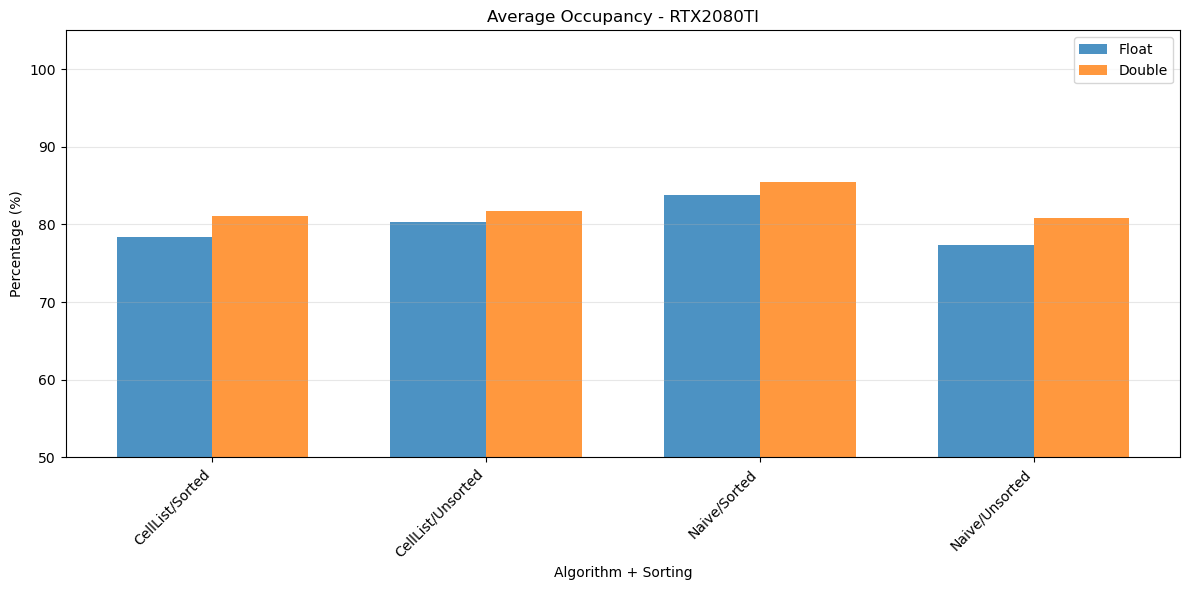

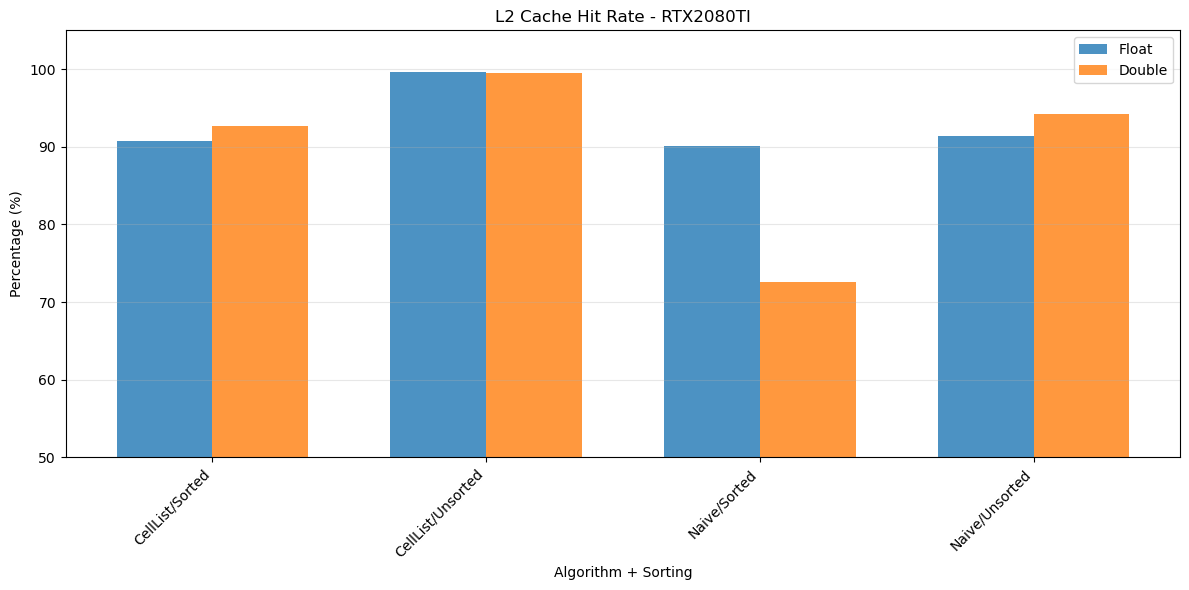

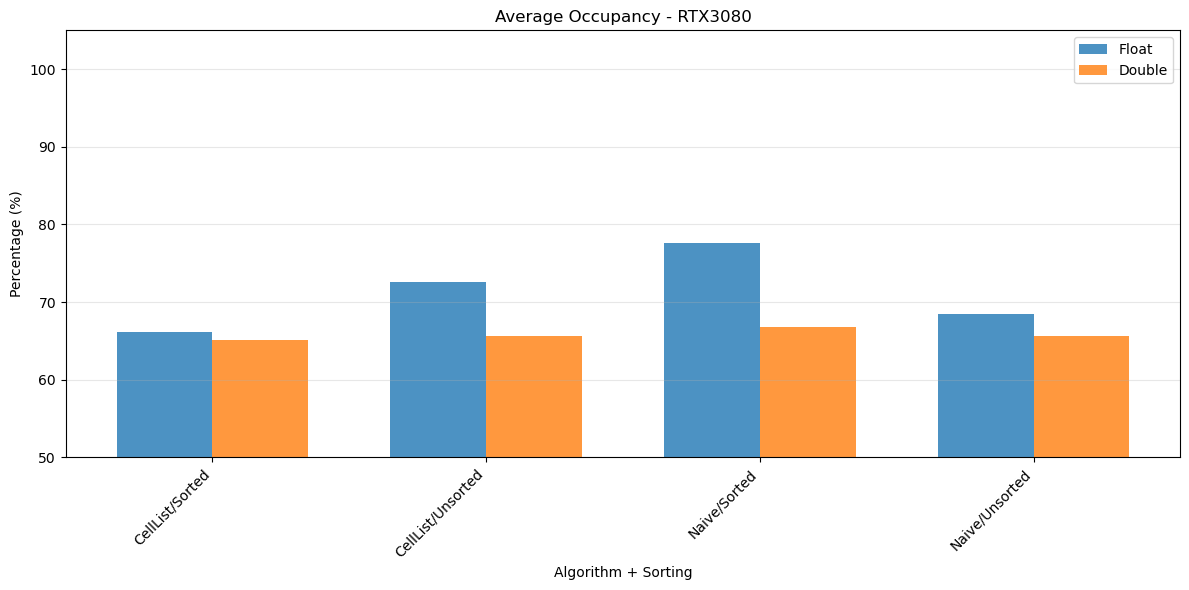

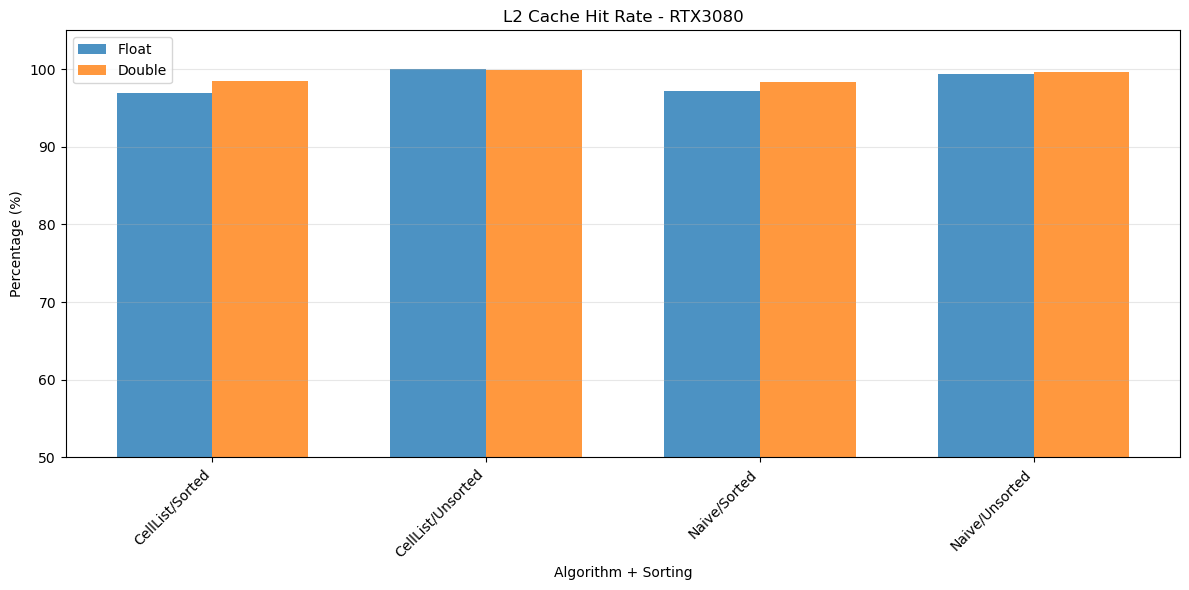

In [55]:
for architecture_unique in nsightdf["Architecture"].unique():
    for metric_unique in nsightdf["Metric"].unique():
        subset = nsightdf
        subset = subset[subset["Architecture"] == architecture_unique]
        subset = subset[subset["Metric"] == metric_unique]
        
        plt.figure(figsize=(12, 6))
        
        # Pivot for grouped bar chart
        pivot_nsightdf = subset.pivot(index=["Algorithm", "Sorted"], columns="Precision", values="Value")
        
        x = np.arange(len(pivot_nsightdf.index))
        width = 0.35
        
        plt.bar(x - width/2, pivot_nsightdf["Float"].values if "Float" in pivot_nsightdf.columns else [], 
                width, label="Float", alpha=0.8)
        plt.bar(x + width/2, pivot_nsightdf["Double"].values if "Double" in pivot_nsightdf.columns else [], 
                width, label="Double", alpha=0.8)
        
        plt.ylim(50,105)
        plt.xlabel('Algorithm + Sorting')
        plt.ylabel('Percentage (%)')
        plt.title(f'{metric_unique} - {architecture_unique}')
        plt.xticks(x, pivot_nsightdf.index.map('/'.join), rotation=45, ha='right')
        plt.legend()
        plt.tight_layout()
        plt.grid(axis='y', alpha=0.3)
        plt.show()